In [1]:
import json
import pandas as pd
import os

In [2]:
DATASET_DIR = r"C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018"

TRAIN_FILE = os.path.join(
    DATASET_DIR,
    "train_features_0.jsonl"
)

TEST_FILE = os.path.join(
    DATASET_DIR,
    "test_features.jsonl"
)

print("Training file:")
print(TRAIN_FILE)

print("\nTest file:")
print(TEST_FILE)

print("\nTraining file exists:", os.path.exists(TRAIN_FILE))
print("Test file exists:", os.path.exists(TEST_FILE))

Training file:
C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018\train_features_0.jsonl

Test file:
C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018\test_features.jsonl

Training file exists: True
Test file exists: True


In [3]:
with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    first_line = f.readline()

record = json.loads(first_line)

print(type(record))
print(record)

<class 'dict'>
{'sha256': '0abb4fda7d5b13801d63bee53e5e256be43e141faa077a6d149874242c3f02c2', 'md5': '63956d6417f8f43357d9a8e79e52257e', 'appeared': '2006-12', 'label': 0, 'avclass': '', 'histogram': [45521, 13095, 12167, 12496, 12429, 11709, 11864, 12057, 12881, 11798, 11802, 11783, 12029, 12081, 11756, 12532, 11980, 11628, 11504, 11715, 11809, 12414, 11779, 11708, 11956, 11622, 11859, 11775, 11717, 11507, 11873, 11781, 12015, 11690, 11676, 11782, 11820, 11859, 12025, 11786, 11731, 11445, 11556, 11676, 12057, 11636, 11669, 11903, 12004, 11741, 11833, 12329, 11778, 11859, 11806, 11586, 11775, 11885, 11863, 12047, 11869, 12077, 11724, 12037, 13129, 11931, 12101, 12202, 11956, 12625, 11877, 11804, 11999, 11869, 11578, 11591, 11933, 12020, 11695, 11915, 12565, 11755, 11597, 12224, 11786, 11709, 12321, 12325, 11671, 11624, 11573, 11879, 11578, 11802, 12060, 11792, 11527, 12248, 11703, 11793, 12143, 12701, 12071, 11871, 12582, 12346, 12303, 11892, 12190, 12011, 11826, 12261, 12139, 11913, 1

In [4]:
print("Number of fields:", len(record))

print("\nFields:")
for key in record.keys():
    print("-", key)

Number of fields: 14

Fields:
- sha256
- md5
- appeared
- label
- avclass
- histogram
- byteentropy
- strings
- general
- header
- section
- imports
- exports
- datadirectories


In [5]:
print("Label:", record.get("label"))

Label: 0


In [6]:
labels = []

with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 10000:
            break

        data = json.loads(line)
        labels.append(data.get("label"))

print(pd.Series(labels).value_counts())

0    10000
Name: count, dtype: int64


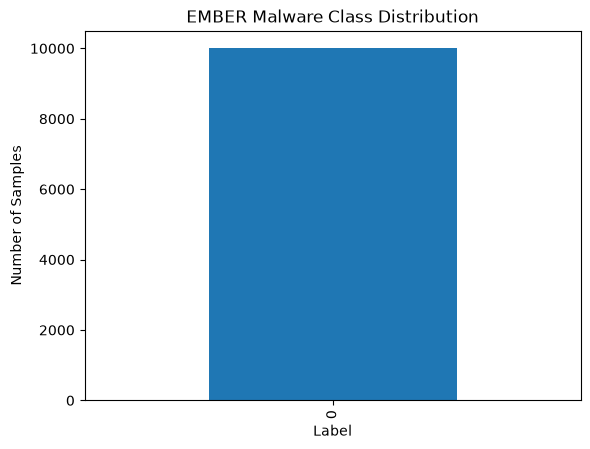

In [7]:
import matplotlib.pyplot as plt

pd.Series(labels).value_counts().plot(
    kind="bar",
    title="EMBER Malware Class Distribution"
)

plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.show()

In [9]:
import os
import json
import glob
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

In [11]:
EMBER_DIR = r"C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018"

print("EMBER directory:")
print(EMBER_DIR)

print("\nFiles:")
for file in glob.glob(os.path.join(EMBER_DIR, "*")):
    print(os.path.basename(file))

EMBER directory:
C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018

Files:
ember_model_2018.txt
test_features.jsonl
train_features_0.jsonl
train_features_1.jsonl
train_features_2.jsonl
train_features_3.jsonl
train_features_4.jsonl
train_features_5.jsonl


In [12]:
file_path = os.path.join(
    EMBER_DIR,
    "train_features_0.jsonl"
)

with open(file_path, "r", encoding="utf-8") as f:
    first_line = f.readline()

record = json.loads(first_line)

print("Number of fields:", len(record))
print("\nFields:")

for key in record.keys():
    print("-", key)

Number of fields: 14

Fields:
- sha256
- md5
- appeared
- label
- avclass
- histogram
- byteentropy
- strings
- general
- header
- section
- imports
- exports
- datadirectories


In [13]:
from collections import Counter

file_path = os.path.join(
    EMBER_DIR,
    "train_features_0.jsonl"
)

labels = []

with open(file_path, "r", encoding="utf-8") as f:

    for i, line in enumerate(f):

        if not line.strip():
            continue

        record = json.loads(line)

        labels.append(record["label"])

        # Only inspect first 10,000 records
        if i >= 9999:
            break

print("Number of records:", len(labels))
print("Label distribution:")
print(Counter(labels))

Number of records: 10000
Label distribution:
Counter({0: 10000})


In [14]:
for filename in sorted(
    glob.glob(os.path.join(EMBER_DIR, "train_features_*.jsonl"))
):

    counter = Counter()

    with open(filename, "r", encoding="utf-8") as f:

        for i, line in enumerate(f):

            if not line.strip():
                continue

            record = json.loads(line)

            counter[record["label"]] += 1

            if i >= 9999:
                break

    print("\n", os.path.basename(filename))
    print(counter)


 train_features_0.jsonl
Counter({0: 10000})

 train_features_1.jsonl
Counter({1: 3786, 0: 3484, -1: 2730})

 train_features_2.jsonl
Counter({0: 3741, 1: 3551, -1: 2708})

 train_features_3.jsonl
Counter({0: 3789, 1: 3450, -1: 2761})

 train_features_4.jsonl
Counter({1: 3793, 0: 3618, -1: 2589})

 train_features_5.jsonl
Counter({1: 4382, 0: 2975, -1: 2643})


In [15]:
import os
import json
import glob
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

In [16]:
EMBER_DIR = r"C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018"

print(os.path.exists(EMBER_DIR))

for file in glob.glob(os.path.join(EMBER_DIR, "*")):
    print(os.path.basename(file))

True
ember_model_2018.txt
test_features.jsonl
train_features_0.jsonl
train_features_1.jsonl
train_features_2.jsonl
train_features_3.jsonl
train_features_4.jsonl
train_features_5.jsonl


In [17]:
file_path = os.path.join(
    EMBER_DIR,
    "train_features_0.jsonl"
)

with open(file_path, "r", encoding="utf-8") as f:
    record = json.loads(f.readline())

print("Number of fields:", len(record))
print("Fields:")

for key in record:
    print("-", key)

Number of fields: 14
Fields:
- sha256
- md5
- appeared
- label
- avclass
- histogram
- byteentropy
- strings
- general
- header
- section
- imports
- exports
- datadirectories


In [18]:
labels = []

with open(file_path, "r", encoding="utf-8") as f:

    for i, line in enumerate(f):

        if not line.strip():
            continue

        record = json.loads(line)

        labels.append(record["label"])

        if i >= 9999:
            break

print(Counter(labels))

Counter({0: 10000})


In [19]:
for filename in sorted(
    glob.glob(os.path.join(EMBER_DIR, "train_features_*.jsonl"))
):

    counter = Counter()

    with open(filename, "r", encoding="utf-8") as f:

        for i, line in enumerate(f):

            if not line.strip():
                continue

            record = json.loads(line)

            counter[record["label"]] += 1

            if i >= 9999:
                break

    print(os.path.basename(filename), "=>", counter)

train_features_0.jsonl => Counter({0: 10000})
train_features_1.jsonl => Counter({1: 3786, 0: 3484, -1: 2730})
train_features_2.jsonl => Counter({0: 3741, 1: 3551, -1: 2708})
train_features_3.jsonl => Counter({0: 3789, 1: 3450, -1: 2761})
train_features_4.jsonl => Counter({1: 3793, 0: 3618, -1: 2589})
train_features_5.jsonl => Counter({1: 4382, 0: 2975, -1: 2643})


In [21]:
import os
import json
import glob
import pandas as pd
from collections import Counter

EMBER_DIR = r"C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018"

train_files = sorted(
    glob.glob(
        os.path.join(
            EMBER_DIR,
            "train_features_*.jsonl"
        )
    )
)

print("Training files found:")
for file in train_files:
    print(os.path.basename(file))

print("\nNumber of training files:", len(train_files))

Training files found:
train_features_0.jsonl
train_features_1.jsonl
train_features_2.jsonl
train_features_3.jsonl
train_features_4.jsonl
train_features_5.jsonl

Number of training files: 6


In [ ]:
all_records = []

for file_path in train_files:

    print(f"Reading: {os.path.basename(file_path)}")

    with open(file_path, "r", encoding="utf-8") as f:

        for line in f:

            if not line.strip():
                continue

            record = json.loads(line)

            all_records.append(record)

print("\nTotal records loaded:", len(all_records))

Reading: train_features_0.jsonl
Reading: train_features_1.jsonl
Reading: train_features_2.jsonl
Reading: train_features_3.jsonl
Reading: train_features_4.jsonl
Reading: train_features_5.jsonl


In [ ]:
labels = list(label_counter.keys())
counts = list(label_counter.values())

label_names = {
    -1: "Unlabeled",
     0: "Benign",
     1: "Malware"
}

plt.figure(figsize=(8, 5))

plt.bar(
    [
        label_names[label]
        for label in labels
    ],
    counts
)

plt.title("EMBER Malware Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Samples")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [1]:
import os
import json
from collections import Counter

MAX_RECORDS_PER_FILE = 10000

all_records = []

print("Starting EMBER dataset loading...")
print("=" * 60)

for file_path in train_files:

    filename = os.path.basename(file_path)

    print(f"\nReading: {filename}")

    count = 0

    with open(file_path, "r", encoding="utf-8") as f:

        for line in f:

            if not line.strip():
                continue

            record = json.loads(line)

            all_records.append(record)

            count += 1

            if count >= MAX_RECORDS_PER_FILE:
                break

            if count % 1000 == 0:
                print(
                    f"  Loaded {count:,} records from {filename}"
                )

    print(
        f"Finished {filename}: "
        f"{count:,} records"
    )

print("\n" + "=" * 60)

print(
    f"TOTAL RECORDS LOADED: "
    f"{len(all_records):,}"
)

print("=" * 60)

Starting EMBER dataset loading...


NameError: name 'train_files' is not defined

In [2]:
import sys
import subprocess

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "xgboost"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

print("All packages installed successfully.")

All packages installed successfully.


In [3]:
import os
import json
import time
import pickle

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.feature_extraction import DictVectorizer

from xgboost import XGBClassifier

print("Imports successful.")

Imports successful.


In [8]:
AI_ROOT = Path(r"C:\Users\MALAY\sentinel\ai")

DATASET_DIR = AI_ROOT / "datasets" / "malware" / "ember2018"

MODEL_DIR = AI_ROOT / "models" / "malware"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("AI ROOT:")
print(AI_ROOT)

print("\nDATASET:")
print(DATASET_DIR)

print("\nMODEL DIRECTORY:")
print(MODEL_DIR)

AI ROOT:
C:\Users\MALAY\sentinel\ai

DATASET:
C:\Users\MALAY\sentinel\ai\datasets\malware\ember2018

MODEL DIRECTORY:
C:\Users\MALAY\sentinel\ai\models\malware


In [9]:
train_files = sorted(
    DATASET_DIR.glob("train_features_*.jsonl")
)

print("EMBER training files:")
print("=" * 60)

for file_path in train_files:

    size_gb = file_path.stat().st_size / (1024 ** 3)

    print(
        f"{file_path.name:25s} "
        f"{size_gb:.2f} GB"
    )

print("=" * 60)

print(
    "Total training files:",
    len(train_files)
)

EMBER training files:
train_features_0.jsonl    0.53 GB
train_features_1.jsonl    1.55 GB
train_features_2.jsonl    1.21 GB
train_features_3.jsonl    1.28 GB
train_features_4.jsonl    1.23 GB
train_features_5.jsonl    1.72 GB
Total training files: 6


In [10]:
with open(
    train_files[0],
    "r",
    encoding="utf-8"
) as f:

    first_line = next(
        line for line in f
        if line.strip()
    )

    first_record = json.loads(first_line)

print("Fields:")
print("=" * 60)

for key in first_record.keys():
    print("-", key)

Fields:
- sha256
- md5
- appeared
- label
- avclass
- histogram
- byteentropy
- strings
- general
- header
- section
- imports
- exports
- datadirectories


In [11]:
print("EMBER record structure")
print("=" * 60)

for key, value in first_record.items():

    if isinstance(value, dict):

        print(
            f"{key:20s} "
            f"dictionary "
            f"({len(value)} fields)"
        )

    elif isinstance(value, list):

        print(
            f"{key:20s} "
            f"list "
            f"({len(value)} items)"
        )

    else:

        print(
            f"{key:20s} "
            f"{type(value).__name__}"
        )

EMBER record structure
sha256               str
md5                  str
appeared             str
label                int
avclass              str
histogram            list (256 items)
byteentropy          list (256 items)
strings              dictionary (9 fields)
general              dictionary (10 fields)
header               dictionary (2 fields)
section              dictionary (2 fields)
imports              dictionary (9 fields)
exports              list (0 items)
datadirectories      list (15 items)


In [49]:
def load_ember_sample(
    files,
    max_records_per_file=6000
):

    records = []

    overall_start = time.time()

    for file_path in files:

        print("\n" + "=" * 60)
        print("Reading:", file_path.name)
        print("=" * 60)

        start = time.time()

        count = 0

        with open(
            file_path,
            "r",
            encoding="utf-8"
        ) as f:

            for line in f:

                if not line.strip():
                    continue

                record = json.loads(line)

                label = record.get("label")

                # Only supervised labels
                if label not in [0, 1]:
                    continue

                records.append(record)

                count += 1

                if count % 500 == 0:

                    elapsed = time.time() - start

                    print(
                        f"{count:,} records "
                        f"| {elapsed:.1f} seconds"
                    )

                if count >= max_records_per_file:
                    break

        print(
            f"Finished {file_path.name}: "
            f"{count:,} labeled records"
        )

    total_time = time.time() - overall_start

    print("\n" + "=" * 60)
    print(
        "TOTAL RECORDS:",
        len(records)
    )

    print(
        "TOTAL TIME:",
        f"{total_time:.2f} seconds"
    )

    print("=" * 60)

    return records


records = load_ember_sample(
    train_files,
    MAX_RECORDS_PER_FILE
)


Reading: train_features_0.jsonl
500 records | 0.1 seconds
1,000 records | 0.2 seconds
1,500 records | 0.4 seconds
2,000 records | 0.5 seconds
2,500 records | 0.6 seconds
3,000 records | 0.7 seconds
3,500 records | 0.8 seconds
4,000 records | 0.9 seconds
4,500 records | 0.9 seconds
5,000 records | 1.0 seconds
5,500 records | 1.1 seconds
6,000 records | 1.2 seconds
6,500 records | 1.3 seconds
7,000 records | 1.4 seconds
7,500 records | 1.5 seconds
8,000 records | 1.6 seconds
8,500 records | 1.7 seconds
9,000 records | 1.8 seconds
9,500 records | 1.8 seconds
10,000 records | 1.9 seconds
Finished train_features_0.jsonl: 10,000 labeled records

Reading: train_features_1.jsonl
500 records | 0.1 seconds
1,000 records | 0.2 seconds
1,500 records | 0.3 seconds
2,000 records | 0.4 seconds
2,500 records | 0.6 seconds
3,000 records | 0.7 seconds
3,500 records | 0.8 seconds
4,000 records | 0.9 seconds
4,500 records | 1.1 seconds
5,000 records | 1.2 seconds
5,500 records | 1.3 seconds
6,000 records

In [13]:
labels = [
    record["label"]
    for record in records
]

label_counts = Counter(labels)

print("Label distribution:")
print(label_counts)

Label distribution:
Counter({0: 34067, 1: 25933})


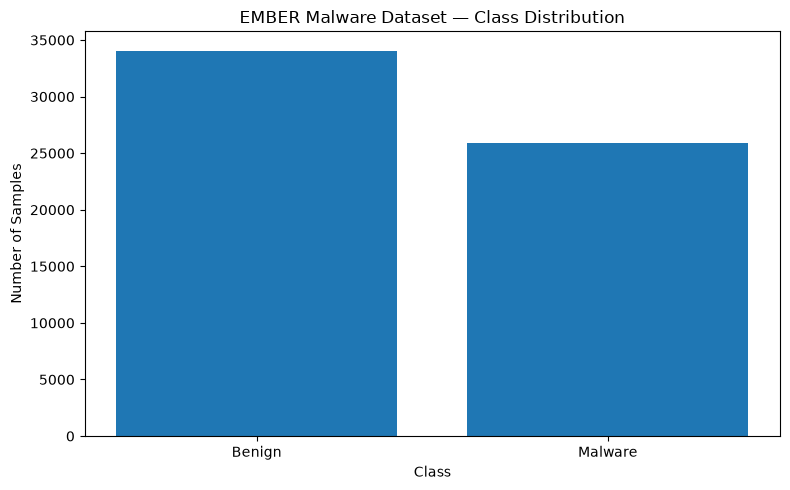

In [14]:
benign_count = label_counts.get(0, 0)
malware_count = label_counts.get(1, 0)

plt.figure(figsize=(8, 5))

plt.bar(
    ["Benign", "Malware"],
    [benign_count, malware_count]
)

plt.title(
    "EMBER Malware Dataset — Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

In [15]:
IGNORED_FIELDS = {
    "sha256",
    "md5",
    "appeared",
    "label",
    "avclass"
}


def flatten_numeric(
    obj,
    prefix="",
    output=None
):

    if output is None:
        output = {}

    # Dictionary
    if isinstance(obj, dict):

        for key, value in obj.items():

            if prefix:
                name = f"{prefix}_{key}"
            else:
                name = str(key)

            flatten_numeric(
                value,
                name,
                output
            )

    # List / array
    elif isinstance(
        obj,
        (list, tuple, np.ndarray)
    ):

        for index, value in enumerate(obj):

            name = f"{prefix}_{index}"

            flatten_numeric(
                value,
                name,
                output
            )

    # Numeric value
    elif isinstance(
        obj,
        (
            int,
            float,
            bool,
            np.integer,
            np.floating
        )
    ):

        value = float(obj)

        if np.isfinite(value):

            output[prefix] = value

    return output

In [16]:
def record_to_features(record):

    features = {}

    for key, value in record.items():

        if key in IGNORED_FIELDS:
            continue

        flatten_numeric(
            value,
            key,
            features
        )

    return features

In [17]:
sample_features = record_to_features(
    records[0]
)

print(
    "Number of extracted features:",
    len(sample_features)
)

print("\nFirst 30 features:")

for key, value in list(
    sample_features.items()
)[:30]:

    print(
        f"{key:50s} = {value}"
    )

Number of extracted features: 683

First 30 features:
histogram_0                                        = 45521.0
histogram_1                                        = 13095.0
histogram_2                                        = 12167.0
histogram_3                                        = 12496.0
histogram_4                                        = 12429.0
histogram_5                                        = 11709.0
histogram_6                                        = 11864.0
histogram_7                                        = 12057.0
histogram_8                                        = 12881.0
histogram_9                                        = 11798.0
histogram_10                                       = 11802.0
histogram_11                                       = 11783.0
histogram_12                                       = 12029.0
histogram_13                                       = 12081.0
histogram_14                                       = 11756.0
histogram_15                   

In [18]:
feature_dicts = []

start = time.time()

for i, record in enumerate(records):

    feature_dicts.append(
        record_to_features(record)
    )

    if (i + 1) % 1000 == 0:

        print(
            f"Processed "
            f"{i+1:,}/{len(records):,}"
        )

print(
    "\nFeature extraction completed in",
    f"{time.time() - start:.2f} seconds"
)

Processed 1,000/60,000
Processed 2,000/60,000
Processed 3,000/60,000
Processed 4,000/60,000
Processed 5,000/60,000
Processed 6,000/60,000
Processed 7,000/60,000
Processed 8,000/60,000
Processed 9,000/60,000
Processed 10,000/60,000
Processed 11,000/60,000
Processed 12,000/60,000
Processed 13,000/60,000
Processed 14,000/60,000
Processed 15,000/60,000
Processed 16,000/60,000
Processed 17,000/60,000
Processed 18,000/60,000
Processed 19,000/60,000
Processed 20,000/60,000
Processed 21,000/60,000
Processed 22,000/60,000
Processed 23,000/60,000
Processed 24,000/60,000
Processed 25,000/60,000
Processed 26,000/60,000
Processed 27,000/60,000
Processed 28,000/60,000
Processed 29,000/60,000
Processed 30,000/60,000
Processed 31,000/60,000
Processed 32,000/60,000
Processed 33,000/60,000
Processed 34,000/60,000
Processed 35,000/60,000
Processed 36,000/60,000
Processed 37,000/60,000
Processed 38,000/60,000
Processed 39,000/60,000
Processed 40,000/60,000
Processed 41,000/60,000
Processed 42,000/60,000
P

In [19]:
y = np.array(
    [
        record["label"]
        for record in records
    ],
    dtype=np.int8
)

print("X records:", len(feature_dicts))
print("y records:", len(y))

print("\nLabels:")
print(Counter(y))

X records: 60000
y records: 60000

Labels:
Counter({np.int8(0): 34067, np.int8(1): 25933})


In [20]:
vectorizer = DictVectorizer(
    sparse=True
)

X = vectorizer.fit_transform(
    feature_dicts
)

print("Machine learning matrix:")
print("=" * 60)

print("Rows:", X.shape[0])
print("Columns:", X.shape[1])

print(
    "Matrix:",
    type(X).__name__
)

Machine learning matrix:
Rows: 60000
Columns: 947
Matrix: csr_matrix


In [21]:
vectorizer_path = (
    MODEL_DIR /
    "ember_vectorizer.pkl"
)

with open(
    vectorizer_path,
    "wb"
) as f:

    pickle.dump(
        vectorizer,
        f
    )

print(
    "Vectorizer saved:"
)

print(vectorizer_path)

Vectorizer saved:
C:\Users\MALAY\sentinel\ai\models\malware\ember_vectorizer.pkl


In [22]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("TRAINING")
print("=" * 40)

print(
    "Samples:",
    X_train.shape[0]
)

print(
    "Labels:",
    Counter(y_train)
)

print("\nTESTING")
print("=" * 40)

print(
    "Samples:",
    X_test.shape[0]
)

print(
    "Labels:",
    Counter(y_test)
)

TRAINING
Samples: 48000
Labels: Counter({np.int8(0): 27254, np.int8(1): 20746})

TESTING
Samples: 12000
Labels: Counter({np.int8(0): 6813, np.int8(1): 5187})


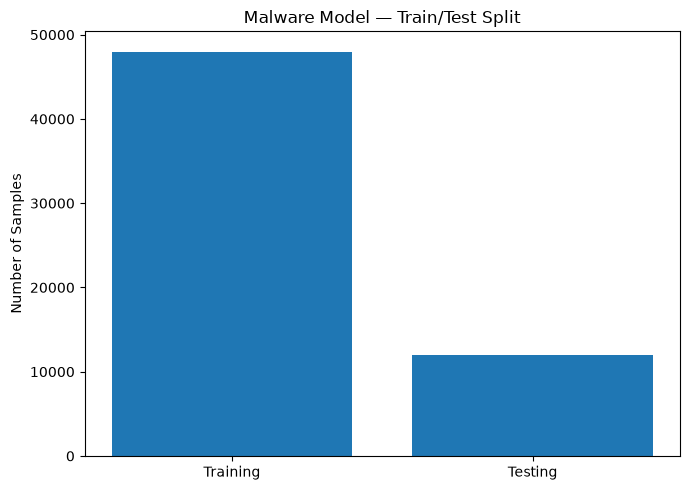

In [23]:
train_total = len(y_train)
test_total = len(y_test)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Training", "Testing"],
    [train_total, test_total]
)

plt.title(
    "Malware Model — Train/Test Split"
)

plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

In [24]:
model = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="binary:logistic",

    eval_metric="logloss",

    random_state=42,

    n_jobs=-1,

    tree_method="hist"
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [25]:
print("Training Sentinel Malware Detection Model...")
print("=" * 60)

start = time.time()

model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_test, y_test)
    ],

    verbose=False
)

training_time = time.time() - start

print(
    "Training completed."
)

print(
    "Training time:",
    f"{training_time:.2f} seconds"
)

Training Sentinel Malware Detection Model...
Training completed.
Training time: 107.57 seconds


In [26]:
y_pred = model.predict(
    X_test
)

y_probability = model.predict_proba(
    X_test
)[:, 1]

print("Predictions generated.")

print(
    "Prediction samples:",
    y_pred[:20]
)

print(
    "Probability samples:",
    y_probability[:20]
)

Predictions generated.
Prediction samples: [0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1]
Probability samples: [2.0434367e-02 2.8242019e-04 4.4720238e-03 2.6113427e-01 4.0723380e-02
 8.4426224e-01 9.1521189e-02 9.9677283e-01 9.6934313e-01 2.8969722e-03
 3.0261654e-02 1.7193951e-01 1.5837407e-02 1.1560230e-01 7.7695777e-03
 9.8045599e-01 1.4519052e-01 9.3388301e-01 9.9512595e-01 9.9281549e-01]


In [27]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("=" * 60)
print("SENTINEL MALWARE MODEL — PERFORMANCE")
print("=" * 60)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc:.4f}"
)

print("=" * 60)

SENTINEL MALWARE MODEL — PERFORMANCE
Accuracy  : 0.9492
Precision : 0.9469
Recall    : 0.9348
F1 Score  : 0.9408
ROC-AUC   : 0.9893


In [28]:
print(
    classification_report(

        y_test,

        y_pred,

        target_names=[
            "Benign",
            "Malware"
        ],

        zero_division=0
    )
)

              precision    recall  f1-score   support

      Benign       0.95      0.96      0.96      6813
     Malware       0.95      0.93      0.94      5187

    accuracy                           0.95     12000
   macro avg       0.95      0.95      0.95     12000
weighted avg       0.95      0.95      0.95     12000



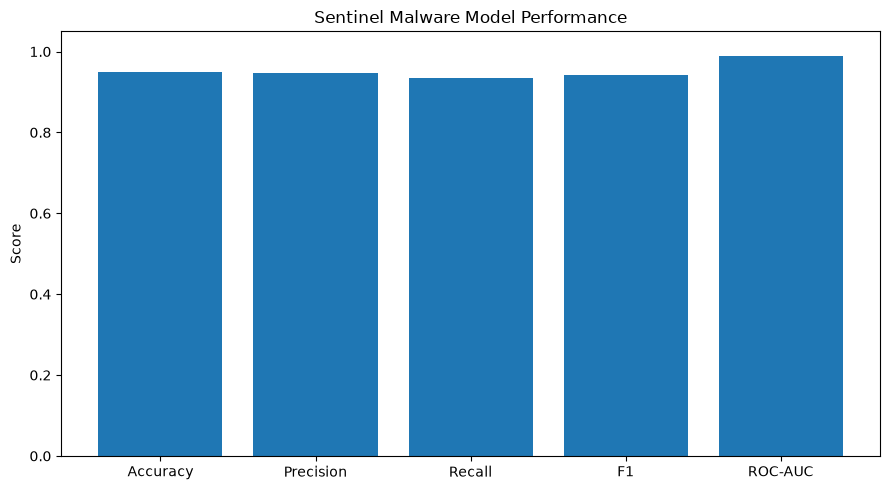

In [29]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

metric_values = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(9, 5))

plt.bar(
    metric_names,
    metric_values
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Sentinel Malware Model Performance"
)

plt.tight_layout()
plt.show()

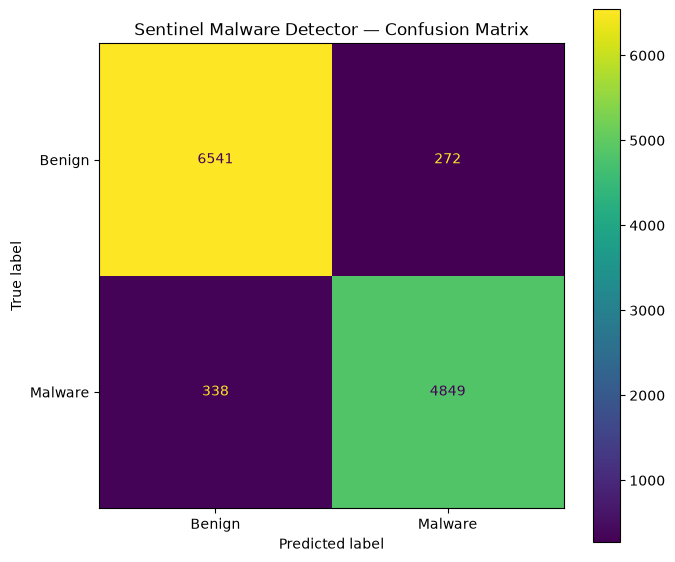

In [30]:
cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Benign",
        "Malware"
    ]
)

display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Sentinel Malware Detector — Confusion Matrix"
)

plt.tight_layout()
plt.show()

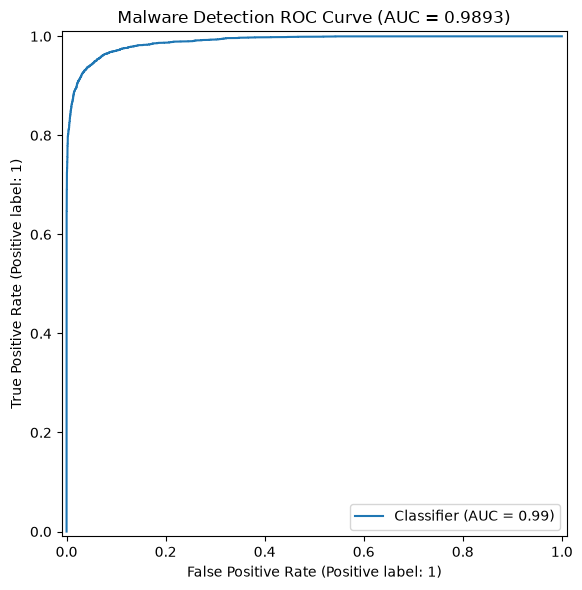

In [31]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    ax=ax
)

ax.set_title(
    f"Malware Detection ROC Curve "
    f"(AUC = {roc_auc:.4f})"
)

plt.tight_layout()
plt.show()

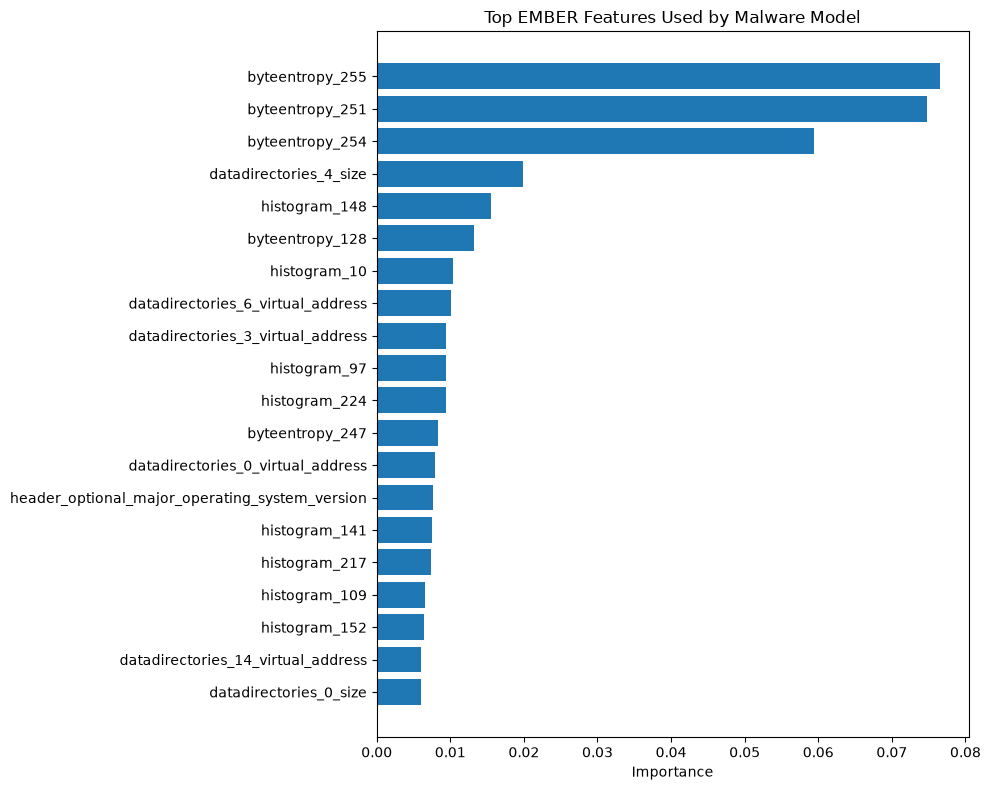

In [32]:
feature_names = np.array(
    vectorizer.get_feature_names_out()
)

importance = (
    model.feature_importances_
)

top_n = min(
    20,
    len(importance)
)

top_indices = np.argsort(
    importance
)[-top_n:][::-1]

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    feature_names[top_indices][::-1],
    importance[top_indices][::-1]
)

plt.xlabel(
    "Importance"
)

plt.title(
    "Top EMBER Features Used by Malware Model"
)

plt.tight_layout()
plt.show()

In [33]:
print(
    "TOP MALWARE DETECTION FEATURES"
)

print("=" * 60)

for index in top_indices:

    print(
        f"{feature_names[index]:60s}"
        f"{importance[index]:.6f}"
    )

TOP MALWARE DETECTION FEATURES
byteentropy_255                                             0.076592
byteentropy_251                                             0.074743
byteentropy_254                                             0.059478
datadirectories_4_size                                      0.019849
histogram_148                                               0.015496
byteentropy_128                                             0.013282
histogram_10                                                0.010322
datadirectories_6_virtual_address                           0.010095
datadirectories_3_virtual_address                           0.009463
histogram_97                                                0.009450
histogram_224                                               0.009375
byteentropy_247                                             0.008286
datadirectories_0_virtual_address                           0.007911
header_optional_major_operating_system_version              0.007599
his

In [34]:
model_path = (
    MODEL_DIR /
    "malware_model.pkl"
)

with open(
    model_path,
    "wb"
) as f:

    pickle.dump(
        model,
        f
    )

print(
    "Malware model saved:"
)

print(model_path)

Malware model saved:
C:\Users\MALAY\sentinel\ai\models\malware\malware_model.pkl


In [35]:
print(
    "Model exists:",
    model_path.exists()
)

print(
    "Vectorizer exists:",
    vectorizer_path.exists()
)

print("\nModel directory:")

for file in MODEL_DIR.iterdir():

    print(
        "-",
        file.name
    )

Model exists: True
Vectorizer exists: True

Model directory:
- ember_vectorizer.pkl
- malware_model.pkl


In [36]:
with open(
    model_path,
    "rb"
) as f:

    loaded_model = pickle.load(f)


with open(
    vectorizer_path,
    "rb"
) as f:

    loaded_vectorizer = pickle.load(f)


print(
    "Model loaded successfully."
)

print(
    "Vectorizer loaded successfully."
)

Model loaded successfully.
Vectorizer loaded successfully.


In [37]:
def predict_record(
    record,
    model,
    vectorizer
):

    features = record_to_features(
        record
    )

    X_one = vectorizer.transform(
        [features]
    )

    probability = float(
        model.predict_proba(
            X_one
        )[0][1]
    )

    prediction = (
        "MALWARE"
        if probability >= 0.50
        else "BENIGN"
    )

    risk_score = probability * 100

    if risk_score >= 80:

        risk_level = "HIGH"

    elif risk_score >= 50:

        risk_level = "MEDIUM"

    else:

        risk_level = "LOW"

    return {
        "prediction": prediction,
        "malware_probability": probability,
        "risk_score": risk_score,
        "risk_level": risk_level,
        "feature_count": len(features)
    }

In [52]:
test_record = records[46580]

result = predict_record(
    test_record,
    loaded_model,
    loaded_vectorizer
)

print("=" * 65)
print("              SENTINEL MALWARE DETECTION")
print("=" * 65)

print(
    f"CLASSIFICATION       : "
    f"{result['prediction']}"
)

print(
    f"MALWARE PROBABILITY  : "
    f"{result['malware_probability'] * 100:.2f}%"
)

print(
    f"RISK SCORE           : "
    f"{result['risk_score']:.2f}/100"
)

print(
    f"RISK LEVEL           : "
    f"{result['risk_level']}"
)

print(
    f"FEATURES EXTRACTED   : "
    f"{result['feature_count']}"
)

print("=" * 65)

              SENTINEL MALWARE DETECTION
CLASSIFICATION       : BENIGN
MALWARE PROBABILITY  : 1.28%
RISK SCORE           : 1.28/100
RISK LEVEL           : LOW
FEATURES EXTRACTED   : 677


In [44]:
def generate_feature_explanation(
    record,
    model,
    vectorizer,
    top_n=10
):

    features = record_to_features(
        record
    )

    X_one = vectorizer.transform(
        [features]
    )

    feature_names = np.array(
        vectorizer.get_feature_names_out()
    )

    nonzero = X_one.toarray()[0]

    contributions = (
        nonzero *
        model.feature_importances_
    )

    indices = np.argsort(
        contributions
    )[-top_n:][::-1]

    explanations = []

    for index in indices:

        if contributions[index] <= 0:
            continue

        explanations.append({

            "feature":
                feature_names[index],

            "value":
                float(nonzero[index]),

            "importance":
                float(
                    model.feature_importances_[
                        index
                    ]
                )
        })

    return explanations

In [45]:
explanations = generate_feature_explanation(
    test_record,
    loaded_model,
    loaded_vectorizer
)

print("=" * 65)
print("WHY DID SENTINEL MAKE THIS DECISION?")
print("=" * 65)

for item in explanations:

    print(
        f"\nFeature    : "
        f"{item['feature']}"
    )

    print(
        f"Value      : "
        f"{item['value']}"
    )

    print(
        f"Importance : "
        f"{item['importance']:.6f}"
    )

WHY DID SENTINEL MAKE THIS DECISION?

Feature    : header_coff_timestamp
Value      : 1271915209.0
Importance : 0.003642

Feature    : datadirectories_4_virtual_address
Value      : 108032.0
Importance : 0.002923

Feature    : section_sections_0_size
Value      : 105472.0
Importance : 0.002113

Feature    : section_sections_0_vsize
Value      : 105044.0
Importance : 0.001985

Feature    : datadirectories_1_virtual_address
Value      : 113152.0
Importance : 0.001783

Feature    : header_optional_sizeof_code
Value      : 105472.0
Importance : 0.001860

Feature    : datadirectories_2_virtual_address
Value      : 114688.0
Importance : 0.001359

Feature    : datadirectories_5_virtual_address
Value      : 122880.0
Importance : 0.001160

Feature    : byteentropy_128
Value      : 9544.0
Importance : 0.013282

Feature    : general_vsize
Value      : 131072.0
Importance : 0.000924


In [46]:
result_path = (
    MODEL_DIR /
    "malware_test_result.json"
)

with open(
    result_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        result,
        f,
        indent=4
    )

print(
    "Result saved:"
)

print(result_path)

Result saved:
C:\Users\MALAY\sentinel\ai\models\malware\malware_test_result.json


In [47]:
print("\n")
print("=" * 70)
print("                 SENTINEL MALWARE MODEL")
print("=" * 70)

print(
    f"Dataset samples     : {len(records):,}"
)

print(
    f"Training samples    : {len(y_train):,}"
)

print(
    f"Testing samples     : {len(y_test):,}"
)

print(
    f"Features            : {X.shape[1]:,}"
)

print(
    f"Accuracy            : {accuracy:.4f}"
)

print(
    f"Precision           : {precision:.4f}"
)

print(
    f"Recall              : {recall:.4f}"
)

print(
    f"F1 Score            : {f1:.4f}"
)

print(
    f"ROC-AUC             : {roc_auc:.4f}"
)

print(
    f"Model               : {model_path}"
)

print(
    f"Vectorizer          : {vectorizer_path}"
)

print("=" * 70)
print("MODEL TRAINING COMPLETE")
print("=" * 70)



                 SENTINEL MALWARE MODEL
Dataset samples     : 60,000
Training samples    : 48,000
Testing samples     : 12,000
Features            : 947
Accuracy            : 0.9492
Precision           : 0.9469
Recall              : 0.9348
F1 Score            : 0.9408
ROC-AUC             : 0.9893
Model               : C:\Users\MALAY\sentinel\ai\models\malware\malware_model.pkl
Vectorizer          : C:\Users\MALAY\sentinel\ai\models\malware\ember_vectorizer.pkl
MODEL TRAINING COMPLETE
